# Financial Inclusion in Pakistan
## Global Findex 2025 Analysis


## Objective

This project analyzes financial inclusion in Pakistan using the Global Findex 2025 data.

It focuses on:
- overall account ownership,
- gender differences in access,
- income-based gaps,
- digital account ownership,
- digital payment usage.

## Executive Summary

This notebook shows that financial inclusion in Pakistan is uneven and shaped by both income and gender.

- Overall account ownership is 27.3%.
- Men have much higher account ownership than women.
- Account ownership increases with income, reaching 43.9% in the richest quintile.
- Digital account ownership and digital payments remain below basic account ownership.

The main takeaway is that access to formal finance is growing, but it is still concentrated among men and higher-income households.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

Matplotlib is building the font cache; this may take a moment.


## Data Overview

This project uses the Global Findex 2025 data, which contains country-level survey responses on financial access, digital finance, and demographic characteristics.

After loading the full dataset, the analysis narrows to Pakistan and uses the survey weight variable to summarize account ownership, gender differences, income gaps, and digital usage patterns.

In [2]:
df = pd.read_csv("findex_microdata_2025_labelled_update112425.csv")

print(df.shape)
df.head()

(144090, 199)


,year,economy,economycode,regionwb,pop_adult,wpid_random,wgt,female,age,educ,inc_q,emp_in,urbanicity,account_fin,account_mob,account,dig_account,borrowed,saved,receive_wages,receive_transfers,receive_pensions,receive_agriculture,merchantpay_dig,pay_utilities,domestic_remittances,anydigpayment,fin2,fin3,fin4,fin5,fin6,fin7,fin8,fin9a,fin9b,fin10,fin11_0,fin11_1,fin11_2,fin11a,fin11b,fin11c,fin11d,fin11e,fin11f,fin13_1,fin13a,fin13b,fin13c,fin13d,fin13e,fin13f,fin13f_1,fin14a,fin14b,fin14c,fin14d,fin14e,fin15,fin16,fin17a,fin17b,fin17c,fin17d,fin17e,fin17f,fin18,fin19,fin20,fin21,fin22a,fin22a_1,fin22b,fin22c,fin22d,fin22e,fin22f,fin22g,fin22h,fin23,fin24,fin24a,fin24b,fin24c,fin24d1,fin24d2,fin24d3,fin25e1,fin25e2,fin25e3,fin25e4,fin26a,fin26b,fin27,fh1,fin28,fh2,fin29,fh2a,fin30,fin31a,fin31b,fin31c,fin31d,fin32,fin33,fin34a,fin34b,fin34c,fin34d,fin35,fin36,fin36a,fin37,fin38,fin39a,fin39b,fin39c,fin39d,fin40,fin41,fin41a,fin42,fin43a,fin43b,fin43c,fin43d,fin44,fin45,internet_use,con1,con2a,con2b,con2c,con2d,con2e,con2f,con2g,con3,con4,con5,con6,con7,con8,con9,con10,con11,con12,con13,con14,con15,con16,con17,con18,con19,con20,con21,con22,con23,con24,con25,con26,con27,con28,con29,con30a,con30b,con30c,con30d,con30e,con30f,con30g,con30h,con31a,con31b,con31c,con31d,con31e,con31f,con31g,con31h,con32,fin46,fin47,fin48a,fin48b,fin48c,fin48d,fin48e,fin48f,fin49a,fin49b,fin49c,fin49d,fin49e,fin49f,fin50,fin51
0,2024,Nicaragua,NIC,Latin America & Caribbean (excluding high income),4830854,111111345,0.927315,1,53,1.0,5.0,1.0,1.0,0,0.0,0,0.0,0.0,0.0,4.0,4.0,4.0,4.0,0.0,4.0,3.0,0.0,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,2.0,NaN,NaN,NaN,2.0,2.0,2.0,NaN,2.0,NaN,2.0,NaN,2.0,2.0,2.0,NaN,NaN,2.0,2.0,2.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,2.0,NaN,2.0,2.0,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,7.0,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,1.0,1.0,NaN,2.0,NaN,NaN,1.0,1.0,1.0,2.0,2.0,NaN,2.0,1,NaN,3.0,1.0,3.0,NaN,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024,Costa Rica,CRI,Latin America & Caribbean (excluding high income),4118576,111111579,1.383884,2,48,2.0,3.0,1.0,1.0,1,NaN,1,0.0,1.0,1.0,1.0,4.0,4.0,4.0,0.0,2.0,3.0,1.0,2,2.0,2.0,6.0,6.0,2.0,4.0,2.0,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,2.0,5.0,4.0,1.0,NaN,2.0,2.0,NaN,2.0,NaN,2.0,NaN,2.0,2.0,1.0,NaN,NaN,1.0,4.0,1.0,2.0,2.0,NaN,NaN,NaN,1.0,2.0,NaN,4.0,2.0,2.0,NaN,2.0,NaN,2.0,NaN,2.0,1.0,2.0,2.0,NaN,1.0,1.0,2.0,1.0,2.0,NaN,NaN,2.0,1.0,NaN,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,5.0,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,1.0,1.0,NaN,1.0,NaN,1.0,1.0,9.0,NaN,2.0,2.0,NaN,2.0,1,NaN,1.0,2.0,NaN,2.0,1.0,1.0,1.0,2.0,1.0,2.0,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2024,Mali,MLI,Sub-Saharan Africa (excluding high income),12725942,111112511,1.323486,1,40,1.0,2.0,1.0,1.0,0,0.0,0,0.0,1.0,1.0,4.0,4.0,4.0,4.0,0.0,4.0,2.0,0.0,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,2.0,1.0,NaN,NaN,NaN,NaN,2.0,2.0,NaN,2.0,2.0,1.0,2.0,2.0,1.0,1.0,NaN,NaN,NaN,2.0,1.0,4.0,2.0,NaN,NaN,NaN,2.0,2.0,NaN,4.0,2.0,2.0,NaN,2.0,NaN,1.0,2.0,2.0,2.0,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,4.0,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,1.0,4.0,1.0,2.0,NaN,NaN,2.0,2.0,NaN,2.0,2.0,NaN,2.0,1,NaN,4.0,1.0,4.0,NaN,2.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2024,Kuwait,KWT,High income,3950

### Pakistan

In [6]:
pakistan = df[df['economy'].eq('Pakistan')].copy()

print('Pakistan sample size:', pakistan.shape[0])
print('Pakistan columns:', pakistan.shape[1])
print(pakistan[['economy', 'economycode']].drop_duplicates())

Pakistan sample size: 1000
Pakistan columns: 199
     economy economycode
40  Pakistan         PAK


## Methodology

The analysis uses survey weights (`wgt`) so the summary measures better reflect the sampled population.

Key variables used here are:
- `account`: whether the respondent has an account,
- `dig_account`: whether the respondent has a digital account,
- `anydigpayment`: whether the respondent made any digital payment,
- `female`: gender indicator,
- `inc_q`: income quintile.

The code first filters the full dataset to Pakistan, then calculates weighted shares for the main financial inclusion indicators.

## Pakistan Focus

This section narrows the analysis to Pakistan and summarizes the main financial inclusion patterns in the sample.

It compares:
- overall account ownership,
- account ownership by gender,
- account ownership by income quintile,
- digital account ownership by gender.

Together, these results show where access is strongest and where the largest gaps remain.

In [11]:
from IPython.display import display


def weighted_share(frame, value_col, weight_col='wgt', positive_value=1):
    clean = frame[[value_col, weight_col]].dropna()
    if clean.empty:
        return np.nan
    indicator = (clean[value_col] == positive_value).astype(float)
    return np.average(indicator, weights=clean[weight_col]) * 100


def weighted_group_share(frame, group_col, value_col, labels, weight_col='wgt', positive_value=1):
    rows = []
    for group_value, group_frame in frame.groupby(group_col, dropna=False):
        rows.append({
            group_col: labels.get(group_value, group_value),
            'weighted_share_pct': weighted_share(group_frame, value_col, weight_col, positive_value),
            'weighted_n': group_frame[weight_col].dropna().sum(),
        })
    result = pd.DataFrame(rows)
    return result.sort_values(group_col).reset_index(drop=True)

overall_summary = pd.DataFrame({
    'indicator': ['Account ownership', 'Digital account ownership', 'Any digital payment'],
    'weighted_share_pct': [
        weighted_share(pakistan, 'account'),
        weighted_share(pakistan, 'dig_account'),
        weighted_share(pakistan, 'anydigpayment'),
    ],
})

gender_summary = weighted_group_share(
    pakistan,
    'female',
    'account',
    {1: 'Women', 2: 'Men'},
)

income_summary = weighted_group_share(
    pakistan,
    'inc_q',
    'account',
    {
        1.0: 'Quintile 1',
        2.0: 'Quintile 2',
        3.0: 'Quintile 3',
        4.0: 'Quintile 4',
        5.0: 'Quintile 5',
    },
)

account_by_gender = weighted_group_share(
    pakistan,
    'female',
    'account',
    {1: 'Women', 2: 'Men'},
)

overall_display = overall_summary.rename(columns={'indicator': 'Indicator', 'weighted_share_pct': 'Weighted share (%)'}).copy()
overall_display['Weighted share (%)'] = overall_display['Weighted share (%)'].round(1)

gender_display = gender_summary.rename(columns={'female': 'Gender', 'weighted_share_pct': 'Weighted share (%)', 'weighted_n': 'Weighted n'}).copy()
gender_display['Weighted share (%)'] = gender_display['Weighted share (%)'].round(1)
gender_display['Weighted n'] = gender_display['Weighted n'].round(1)

income_display = income_summary.rename(columns={'inc_q': 'Income quintile', 'weighted_share_pct': 'Weighted share (%)', 'weighted_n': 'Weighted n'}).copy()
income_display['Weighted share (%)'] = income_display['Weighted share (%)'].round(1)
income_display['Weighted n'] = income_display['Weighted n'].round(1)

display(overall_display)
display(gender_display)
display(income_display)

,Indicator,Weighted share (%)
0,Account ownership,27.3
1,Digital account ownership,19.8
2,Any digital payment,24.6


,Gender,Weighted share (%),Weighted n
0,Men,42.3,506.4
1,Women,11.9,493.6


,Income quintile,Weighted share (%),Weighted n
0,Quintile 1,14.1,199.6
1,Quintile 2,13.1,200.0
2,Quintile 3,28.2,200.8
3,Quintile 4,37.1,199.7
4,Quintile 5,43.9,199.9


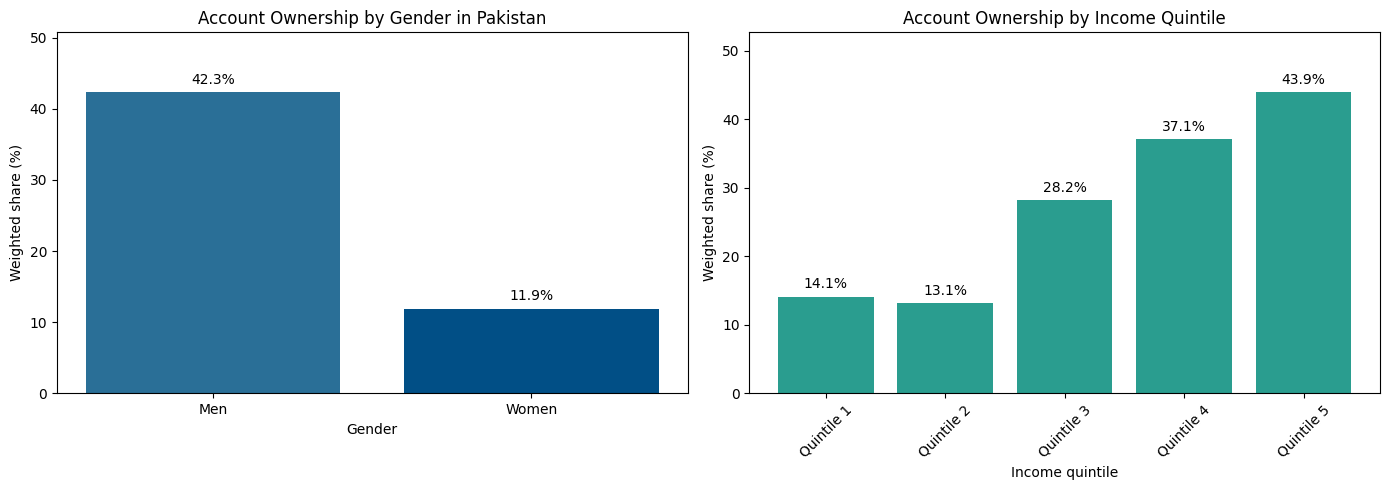

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(gender_summary['female'], gender_summary['weighted_share_pct'], color=['#2a6f97', '#014f86'])
axes[0].set_title('Account Ownership by Gender in Pakistan')
axes[0].set_ylabel('Weighted share (%)')
axes[0].set_xlabel('Gender')
axes[0].set_ylim(0, max(gender_summary['weighted_share_pct']) * 1.2)
for index, value in enumerate(gender_summary['weighted_share_pct']):
    axes[0].text(index, value + 0.8, f'{value:.1f}%', ha='center', va='bottom')

axes[1].bar(income_summary['inc_q'], income_summary['weighted_share_pct'], color='#2a9d8f')
axes[1].set_title('Account Ownership by Income Quintile')
axes[1].set_ylabel('Weighted share (%)')
axes[1].set_xlabel('Income quintile')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylim(0, max(income_summary['weighted_share_pct']) * 1.2)
for index, value in enumerate(income_summary['weighted_share_pct']):
    axes[1].text(index, value + 0.8, f'{value:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

## Interpretation

Account ownership rises sharply with income, and men are substantially more likely than women to own an account in Pakistan.

Digital account ownership and digital payments are lower than overall account ownership, which suggests that access to the formal financial system does not automatically translate into digital use.

These gaps point to two central issues for financial inclusion policy: closing the gender gap and expanding access beyond higher-income households.

## Gender Gap

The gender gap is one of the most striking findings in the Pakistan sample.

- Account ownership among men is about 42.3%.
- Account ownership among women is about 11.9%.
- Digital account ownership is about 34.1% for men versus 5.3% for women.

This shows that the gap is not only about access to an account, but also about access to digital financial services.

,female,weighted_share_pct,weighted_n
0,Men,34.075074,506.357532
1,Women,5.255218,493.642468


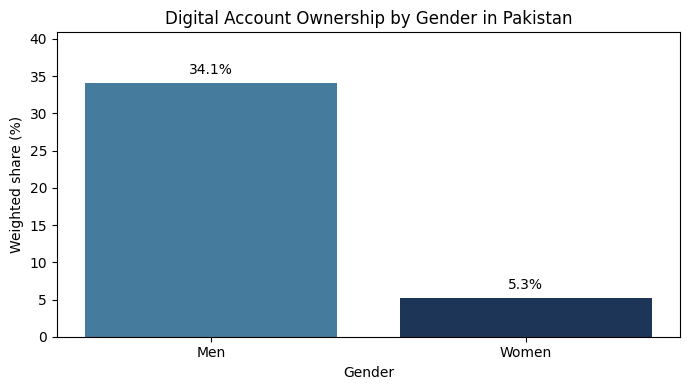

In [13]:
digital_gender_summary = weighted_group_share(
    pakistan,
    'female',
    'dig_account',
    {1: 'Women', 2: 'Men'},
)

display(digital_gender_summary)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(digital_gender_summary['female'], digital_gender_summary['weighted_share_pct'], color=['#457b9d', '#1d3557'])
ax.set_title('Digital Account Ownership by Gender in Pakistan')
ax.set_ylabel('Weighted share (%)')
ax.set_xlabel('Gender')
ax.set_ylim(0, max(digital_gender_summary['weighted_share_pct']) * 1.2)
for index, value in enumerate(digital_gender_summary['weighted_share_pct']):
    ax.text(index, value + 0.8, f'{value:.1f}%', ha='center', va='bottom')
plt.tight_layout()
plt.show()

## Conclusion

Pakistan’s Global Findex 2025 profile shows two linked challenges: expanding basic account ownership and narrowing the gender gap in both account use and digital finance. The clearest gains will come from policies that make formal accounts easier to open and use, while also reducing barriers for women and lower-income households. Overall, the data show that financial inclusion in Pakistan is improving unevenly, and digital adoption is still lagging behind basic access.

## Limitations

This is a cross-sectional snapshot of survey data, so it shows associations rather than causal relationships. The results are also limited to the variables available in the Global Findex microdata and to the Pakistan sample used in this notebook.